# Final Plan: Fine-Tune Plan 1 model on ShanghaiTech A+B

**Strategy:** Plan 1 Model -> fine-tune on Part A+B+C(India) combined (70 images) -> adaptive sigma -> training

## Cell 0: Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
BASE='/content/drive/MyDrive/DLENDSEM'
PLAN1=f'{BASE}/plan1_csrnet'
FINAL=f'{BASE}/final_v2'
SHA=f'{BASE}/dataset/ShanghaiTech'
for d in [f'{FINAL}/density_maps_train_B',f'{FINAL}/density_maps_test_B',f'{FINAL}/checkpoints',f'{FINAL}/results',f'{FINAL}/visualizations']:
    os.makedirs(d,exist_ok=True)
print('Folders ready')

Mounted at /content/drive
Folders ready


In [3]:
DATASET_DIR = '/content/drive/MyDrive/DLENDSEM/dataset'
SHA_DIR = f'{DATASET_DIR}' # Corrected: ShanghaiTech content is directly in DATASET_DIR

import os
import glob # Import glob here

if os.path.exists(f'{SHA_DIR}/part_A_final/train_data/images') and len(glob.glob(f'{SHA_DIR}/part_A_final/train_data/images/*.jpg')) > 0:
    print("✅ Dataset already exists in Drive and is complete, skipping download.")
else:
    !pip install gdown -q
    !gdown 16dhJn7k4FWVwByRsQAEpl9lwjuV03jVI -O /content/shanghaitech.zip
    # Use -o to force overwrite without prompting
    !unzip -o -q /content/shanghaitech.zip -d {DATASET_DIR}
    print("✅ Dataset downloaded and extracted to Drive.")

✅ Dataset already exists in Drive and is complete, skipping download.


In [7]:
!pip install bing-image-downloader -q
from bing_image_downloader import downloader
import shutil, glob, os

FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'
C_DIR = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech/part_C_india'
for d in [f'{C_DIR}/train_data/images', f'{C_DIR}/test_data/images',
          f'{FINAL}/density_maps_train_C', f'{FINAL}/density_maps_test_C']:
    os.makedirs(d, exist_ok=True)

# Download ~100 images across multiple queries
queries = [
    'indian crowd gathering aerial view',
    'kumbh mela crowd',
    'indian railway station crowd',
    'indian festival crowd dense',
    'indian market crowd top view',
    'india election rally crowd',
    'indian temple crowd gathering',
    'indian street crowd busy',
]
tmp = '/content/indian_crowd_tmp'
for q in queries:
    try:
        downloader.download(q, limit=15, output_dir=tmp, adult_filter_off=False,
                           force_replace=False, timeout=30)
    except: pass

# Collect all downloaded images
all_imgs = []
for ext in ['*.jpg','*.jpeg','*.png','*.bmp']:
    all_imgs.extend(glob.glob(f'{tmp}/**/{ext}', recursive=True))
print(f'Downloaded: {len(all_imgs)} images')

# Filter valid images and rename sequentially
from PIL import Image
valid = []
for ip in all_imgs:
    try:
        img = Image.open(ip).convert('RGB')
        w, h = img.size
        if w >= 256 and h >= 256:  # skip tiny images
            valid.append(ip)
    except: pass
print(f'Valid (>=256px): {len(valid)}')

# Split: first 70 train, next 15 test
import random
random.seed(42)
random.shuffle(valid)
train_imgs = valid[:70]
test_imgs = valid[70:85]

for i, ip in enumerate(train_imgs):
    img = Image.open(ip).convert('RGB')
    img.save(f'{C_DIR}/train_data/images/IMG_C_{i+1:03d}.jpg')
for i, ip in enumerate(test_imgs):
    img = Image.open(ip).convert('RGB')
    img.save(f'{C_DIR}/test_data/images/IMG_C_{i+1:03d}.jpg')

print(f'Part C: {len(train_imgs)} train, {len(test_imgs)} test')
print(f'Saved to: {C_DIR}')

[%] Downloading Images to /content/indian_crowd_tmp/indian crowd gathering aerial view


[!!]Indexing page: 1

[%] Indexed 15 Images on Page 1.


[%] Downloading Image #1 from https://imgcdn.stablediffusionweb.com/2024/4/2/63b108b9-5da3-44f8-97ee-7f98271c2985.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://thumbs.dreamstime.com/b/aerial-view-large-indian-crowd-holi-festival-march-aerial-view-large-indian-crowd-holi-festival-256094056.jpg
[%] File Downloaded !

[%] Downloading Image #3 from https://static.vecteezy.com/system/resources/previews/024/250/121/large_2x/ai-generated-people-crowd-gathering-in-the-street-aerial-view-photo.jpg
[!] Issue getting: https://static.vecteezy.com/system/resources/previews/024/250/121/large_2x/ai-generated-people-crowd-gathering-in-the-street-aerial-view-photo.jpg
[!] Error:: HTTP Error 403: Forbidden
[%] Downloading Image #3 from https://thumbs.dreamstime.com/b/aerial-view-image-large-group-indian-people-big-crowd-giant-tricolor-flag-a

## Cell 1: Install & Imports

In [4]:
!pip install scipy h5py matplotlib opencv-python-headless gdown -q
import torch,torch.nn as nn,torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from PIL import Image
import numpy as np,h5py,cv2,glob,os,random,json,time
import scipy.io as io
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree
print(f'PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.10.0+cu128 | GPU: Tesla T4


## Cell 2: Download Plan 1 CSRNet Pretrained Weights
From the first plan trained on ShanghaiA model with MAE: 76.25 | MSE: 116.00.

In [50]:
import gdown
import os

FINAL='/content/drive/MyDrive/DLENDSEM/final_plan'
PRETRAINED=f'{FINAL}/pretrained/plan_1_partA.pth.tar'

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(PRETRAINED), exist_ok=True)

if not os.path.exists(PRETRAINED):
    print('Downloading PLSN 1 CSRNet Part A weights (MAE: 76.25 | MSE: 116.00)...')
    gdown.download(id='1Z-atzS5Y2pOd-nEWqZRVBDMYJDreGWHH',output=PRETRAINED,quiet=False)
    print('Downloaded!')
else:
    print(f'Already have: {PRETRAINED}')

Downloading...
From (original): https://drive.google.com/uc?id=1Z-atzS5Y2pOd-nEWqZRVBDMYJDreGWHH
From (redirected): https://drive.google.com/uc?id=1Z-atzS5Y2pOd-nEWqZRVBDMYJDreGWHH&confirm=t&uuid=27980e93-740f-46ae-a9fd-b1600ebbe125
To: /content/drive/MyDrive/DLENDSEM/final_plan/pretrained/plan_1_partA.pth.tar
100%|██████████| 130M/130M [00:03<00:00, 38.7MB/s]

Downloaded!


## Cell 3: Adaptive Sigma Density Maps (A+B)

In [ ]:
import os
import glob

# Inspect a sample ground-truth directory to check file naming convention
SHA='/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech'
# Corrected path: often 'ground-truth' instead of 'ground_truth'
sample_gt_dir = f'{SHA}/part_A/train_data/ground_truth' # Changed hyphen to underscore
print(f'Listing contents of: {sample_gt_dir}')
# List the first 10 files to get an idea of the naming
try:
    files = sorted(os.listdir(sample_gt_dir))
    for i, f in enumerate(files):
        if i < 10:
            print(f)
        else:
            break
    if not files:
        print(f'No files found in {sample_gt_dir}. This might indicate an empty directory or incorrect path.')
except FileNotFoundError:
    print(f"Error: Directory '{sample_gt_dir}' not found. Please ensure the ShanghaiTech dataset is correctly uploaded and the path is accurate.")
    print("Common variations: 'ground-truth' vs 'ground_truth'. This code assumes 'ground_truth'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


# Also check if any .mat files exist without the GT_ prefix
print('\nChecking for .mat files without "GT_" prefix:')
try:
    non_gt_files = glob.glob(f'{sample_gt_dir}/*.mat')
    if non_gt_files:
        print(f'Found {len(non_gt_files)} .mat files. Sample: {os.path.basename(non_gt_files[0])}')
    else:
        print('No .mat files found in the ground-truth directory.')
except FileNotFoundError:
    # This might happen if sample_gt_dir was not found above and glob is called on a non-existent path
    print(f"Cannot check for .mat files as directory '{sample_gt_dir}' does not exist.")

Listing contents of: /content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech/part_A/train_data/ground_truth
GT_IMG_1.mat
GT_IMG_10.mat
GT_IMG_100.mat
GT_IMG_101.mat
GT_IMG_102.mat
GT_IMG_103.mat
GT_IMG_104.mat
GT_IMG_105.mat
GT_IMG_106.mat
GT_IMG_107.mat

Checking for .mat files without "GT_" prefix:
Found 300 .mat files. Sample: GT_IMG_110.mat


In [ ]:
import os
import glob
from PIL import Image
import numpy as np
import h5py
from scipy.ndimage import gaussian_filter
import scipy.io as io
from tqdm import tqdm

def gen_density_fixed(img_path, gt_path, sigma=15):
    img = Image.open(img_path)
    iw, ih = img.size
    mat = io.loadmat(gt_path)
    pts = mat['image_info'][0,0][0,0][0]
    density = np.zeros((ih, iw), dtype=np.float32)
    if len(pts) == 0:
        return density
    for p in pts:
        x = min(int(round(p[0])), iw-1)
        y = min(int(round(p[1])), ih-1)
        density[y, x] = 1.0
    density = gaussian_filter(density, sigma=sigma)
    return density

def process_split(img_dir, gt_dir, out_dir, label):
    os.makedirs(out_dir, exist_ok=True) # Add this line to create the output directory
    imgs = sorted(glob.glob(f'{img_dir}/*.jpg'))
    done = 0
    for ip in tqdm(imgs, desc=f'[{label}] Processing images'):
        fname = os.path.basename(ip).replace('.jpg','')
        h5p = f'{out_dir}/{fname}.h5'
        if os.path.exists(h5p):
            done += 1; continue
        gp = f'{gt_dir}/GT_{fname}.mat'
        if not os.path.exists(gp): continue
        den = gen_density_fixed(ip, gp)
        with h5py.File(h5p, 'w') as hf:
            hf['density'] = den
        done += 1
    print(f'[{label}] {done}/{len(imgs)} done')

SHA = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech'
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'
process_split(f'{SHA}/part_A/train_data/images', f'{SHA}/part_A/train_data/ground_truth', f'{FINAL}/density_maps_train_A', 'A Train')
process_split(f'{SHA}/part_A/test_data/images', f'{SHA}/part_A/test_data/ground_truth', f'{FINAL}/density_maps_test_A', 'A Test')
process_split(f'{SHA}/part_B/train_data/images', f'{SHA}/part_B/train_data/ground_truth', f'{FINAL}/density_maps_train_B', 'B Train')
process_split(f'{SHA}/part_B/test_data/images', f'{SHA}/part_B/test_data/ground_truth', f'{FINAL}/density_maps_test_B', 'B Test')
print('Density maps done!')

[A Train] Processing images: 100%|██████████| 300/300 [00:43<00:00,  6.88it/s]


[A Train] 300/300 done


[A Test] Processing images: 100%|██████████| 182/182 [02:36<00:00,  1.16it/s]


[A Test] 182/182 done


[B Train] Processing images: 100%|██████████| 400/400 [05:12<00:00,  1.28it/s]


[B Train] 400/400 done


[B Test] Processing images: 100%|██████████| 316/316 [04:02<00:00,  1.30it/s]

[B Test] 316/316 done
Density maps done!


## Cell 4: Dataset & Model

In [6]:
class CrowdDataset(Dataset):
    def __init__(self, img_paths, h5_dirs, crop=256, augment=True):
        self.img_paths = img_paths
        self.h5_dirs = h5_dirs if isinstance(h5_dirs, list) else [h5_dirs]
        self.crop = crop
        self.augment = augment
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
        ])
    def __len__(self): return len(self.img_paths)
    def _find_h5(self, fname):
        for d in self.h5_dirs:
            p = os.path.join(d, f'{fname}.h5')
            if os.path.exists(p): return p
        return None
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        fname = os.path.basename(self.img_paths[idx]).replace('.jpg','')
        with h5py.File(self._find_h5(fname), 'r') as f:
            den = np.array(f['density'], dtype=np.float32)
        w, h = img.size
        cs = self.crop
        # Pad if smaller than crop
        if h < cs or w < cs:
            pad_h, pad_w = max(cs-h, 0), max(cs-w, 0)
            img = np.array(img)
            img = np.pad(img, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
            img = Image.fromarray(img)
            den = np.pad(den, ((0,pad_h),(0,pad_w)), mode='constant')
            w, h = img.size
        # Random crop
        if self.augment:
            t = random.randint(0, h - cs)
            l = random.randint(0, w - cs)
        else:
            t, l = (h-cs)//2, (w-cs)//2
        img = img.crop((l, t, l+cs, t+cs))
        den = den[t:t+cs, l:l+cs]
        # Random horizontal flip
        if self.augment and random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            den = np.fliplr(den).copy()
        # Downsample density to 1/8
        den = cv2.resize(den, (cs//8, cs//8), interpolation=cv2.INTER_CUBIC) * 64
        return self.tf(img), torch.tensor(den).unsqueeze(0)

class CSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])
        self.backend = nn.Sequential(
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(512,256,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(256,128,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(128,64, 3,padding=2,dilation=2), nn.ReLU(True))
        self.output_layer = nn.Conv2d(64, 1, 1)
        for m in self.backend.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None: nn.init.constant_(m.bias, 0)
    def forward(self, x):
        return self.output_layer(self.backend(self.frontend(x)))

print('Model & Dataset defined')

Model & Dataset defined


## Cell 5: Build Combined A+B DataLoader

In [36]:
PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'
SHA = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech'
C_DIR = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech/part_C_india'

imgs_A = sorted(glob.glob(f'{SHA}/part_A/train_data/images/*.jpg'))
imgs_B = sorted(glob.glob(f'{SHA}/part_B/train_data/images/*.jpg'))
imgs_C = sorted(glob.glob(f'{C_DIR}/train_data/images/*.jpg'))
all_imgs = imgs_A + imgs_B + imgs_C

# Part A uses Plan 1 density maps, Part B and C use our new ones
h5_dirs = [f'{PLAN1}/density_maps_train', f'{FINAL}/density_maps_train_B', f'{FINAL}/density_maps_train_C']

train_ds = CrowdDataset(all_imgs, h5_dirs, crop=256, augment=True)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
print(f'Combined: {len(train_ds)} images (A:{len(imgs_A)} + B:{len(imgs_B)} + C:{len(imgs_C)})')

Combined: 770 images (A:300 + B:400 + C:70)


## Cell 6: Load Plan 1 Weights

In [ ]:
model=CSRNet().cuda()
FINAL='/content/drive/MyDrive/DLENDSEM/final_plan'
PRETRAINED=f'{PLAN1}/pretrained/plan1_partA.pth.tar'

if isinstance(checkpoint,dict) and 'state_dict' in checkpoint:
    state=checkpoint['state_dict']
    epoch_info=checkpoint.get('epoch','?')
    best_mae=checkpoint.get('best_prec1','?')
    print(f'Best checkpoint: epoch={epoch_info}, best_mae={best_mae}')
else:
    state=checkpoint

new_state={}
for k,v in state.items():
    nk=k.replace('module.','')
    new_state[nk]=v

missing,unexpected=model.load_state_dict(new_state,strict=False)
if missing: print(f'Missing keys: {missing}')
if unexpected: print(f'Unexpected keys: {unexpected}')
if not missing and not unexpected: print('All weights loaded perfectly!')
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

Best checkpoint: epoch=436, best_mae=76.25
All weights loaded perfectly!
Total params: 16,263,489


## Cell 7: Training
Early stopping patience=30

In [ ]:
import torch,torch.nn as nn

NUM_EPOCHS = 500
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

if 'model' not in locals() or not isinstance(model, nn.Module):
    PRETRAINED_LOAD_PATH='/content/drive/MyDrive/DLENDSEM/final_plan/pretrained/plan_1_partA.pth.tar'
    model = CSRNet().cuda()
    checkpoint = torch.load(PRETRAINED_LOAD_PATH, map_location='cpu', weights_only=False)

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state = checkpoint['state_dict']
    else:
        state = checkpoint

    new_state = {}
    for k, v in state.items():
        nk = k.replace('module.', '')
        new_state[nk] = v

    model.load_state_dict(new_state, strict=False)
    print('Model re-initialized and pretrained weights loaded for current cell execution.')

for p in model.frontend.parameters():
    p.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} (backend+output)')

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

losses = []
existing = sorted(glob.glob(f'{FINAL}/checkpoints/epoch_*.pth'))
start = 0
if existing:
    try:
        # Safely extract epoch number
        epoch_str = existing[-1].split('_epoch_')[1].split('.pth')[0]
        start = int(epoch_str)
        model.load_state_dict(torch.load(existing[-1], map_location='cpu'))
        model.cuda()
        print(f'Resuming from epoch {start}')
    except (IndexError, ValueError) as e:
        print(f'Warning: Could not parse epoch from {existing[-1]} due to {e}. Starting from epoch 0.')
        start = 0
lf = f'{FINAL}/results/losses.json'
if os.path.exists(lf):
    with open(lf) as f: losses = json.load(f)

best_loss = float('inf')
no_improve = 0
PATIENCE = 30

t0 = time.time()
for ep in range(start, NUM_EPOCHS):
    model.train()
    ep_loss = 0
    for imgs, dens in train_loader:
        out = model(imgs.cuda())
        loss = criterion(out, dens.cuda())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    scheduler.step()
    avg = ep_loss / len(train_loader)
    losses.append(avg)
    if avg < best_loss:
        best_loss = avg
        no_improve = 0
        torch.save(model.state_dict(), f'{FINAL}/checkpoints/best_model.pth')
    else:
        no_improve += 1
    if (ep+1) % 1 == 0:
        mins = (time.time()-t0)/60
        print(f'[{ep+1}/{NUM_EPOCHS}] Loss:{avg:.6f} | {mins:.1f}min')
    if (ep+1) % 25 == 0:
        torch.save(model.state_dict(), f'{FINAL}/checkpoints/epoch_{ep+1}.pth')
        with open(lf,'w') as f: json.dump(losses, f)
    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {ep+1}')
        break

torch.save(model.state_dict(), f'{FINAL}/checkpoints/final_model.pth')
with open(lf,'w') as f: json.dump(losses, f)
print('Training complete!')

Trainable: 8,628,225 (backend+output)
[1/500] Loss:0.001347 | 7.0min
[2/500] Loss:0.001350 | 7.3min
[3/500] Loss:0.001299 | 7.6min
[4/500] Loss:0.001354 | 7.9min
[5/500] Loss:0.001333 | 8.2min
[6/500] Loss:0.001299 | 8.5min
[7/500] Loss:0.001336 | 8.8min
[8/500] Loss:0.001377 | 9.1min
[9/500] Loss:0.001314 | 9.4min
[10/500] Loss:0.001404 | 9.7min
[11/500] Loss:0.001329 | 10.0min
[12/500] Loss:0.001267 | 10.3min
[13/500] Loss:0.001264 | 10.6min
[14/500] Loss:0.001323 | 10.9min
[15/500] Loss:0.001341 | 11.2min
[16/500] Loss:0.001312 | 11.5min
[17/500] Loss:0.001359 | 11.8min
[18/500] Loss:0.001293 | 12.1min
[19/500] Loss:0.001261 | 12.4min
[20/500] Loss:0.001240 | 12.7min
[21/500] Loss:0.001373 | 13.0min
[22/500] Loss:0.001261 | 13.3min
[23/500] Loss:0.001331 | 13.6min
[24/500] Loss:0.001338 | 13.9min
[25/500] Loss:0.001370 | 14.2min
[26/500] Loss:0.001376 | 14.5min
[27/500] Loss:0.001336 | 14.8min
[28/500] Loss:0.001316 | 15.1min
[29/500] Loss:0.001264 | 15.4min
[30/500] Loss:0.001311 |

## Cell 9: Evaluate Part A & Part B

In [ ]:
PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'
SHA = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech'

tf_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

def evaluate(model, test_imgs, h5_dir, label):
    model.eval()
    mae_s, mse_s, results = 0, 0, []
    with torch.no_grad():
        for i, ip in enumerate(test_imgs):
            fname = os.path.basename(ip).replace('.jpg','')
            img = Image.open(ip).convert('RGB')
            inp = tf_eval(img).unsqueeze(0).cuda()
            h5p = f'{h5_dir}/{fname}.h5'
            with h5py.File(h5p, 'r') as f:
                gt = float(np.array(f['density']).sum())
            pred = model(inp).sum().item()
            err = abs(pred - gt)
            mae_s += err
            mse_s += err**2
            results.append({'file':fname, 'gt':round(gt,2), 'pred':round(pred,2), 'err':round(err,2)})
            if (i+1) % 60 == 0:
                print(f'  [{label}] {i+1}/{len(test_imgs)}')
    n = len(test_imgs)
    mae, mse = mae_s/n, (mse_s/n)**0.5
    print(f'  {label}: MAE={mae:.2f}  MSE={mse:.2f}')
    return {'mae':round(mae,2), 'mse':round(mse,2), 'n':n, 'per_image':results}

test_A = sorted(glob.glob(f'{SHA}/part_A/test_data/images/*.jpg'))
test_B = sorted(glob.glob(f'{SHA}/part_B/test_data/images/*.jpg'))

print('Evaluating...')
res_A = evaluate(model, test_A, f'{FINAL}/density_maps_test_A', 'Part A')
res_B = evaluate(model, test_B, f'{FINAL}/density_maps_test_B', 'Part B')

with open(f'{FINAL}/results/eval.json','w') as f:
    json.dump({'partA':res_A, 'partB':res_B}, f, indent=2)
print('Saved!')

Evaluating...
  [Part A] 60/182
  [Part A] 120/182
  [Part A] 180/182
  Part A: MAE=63.31  MSE=109.62
  [Part B] 60/316
  [Part B] 120/316
  [Part B] 180/316
  [Part B] 240/316
  [Part B] 300/316
  Part B: MAE=8.37  MSE=13.38
Saved!


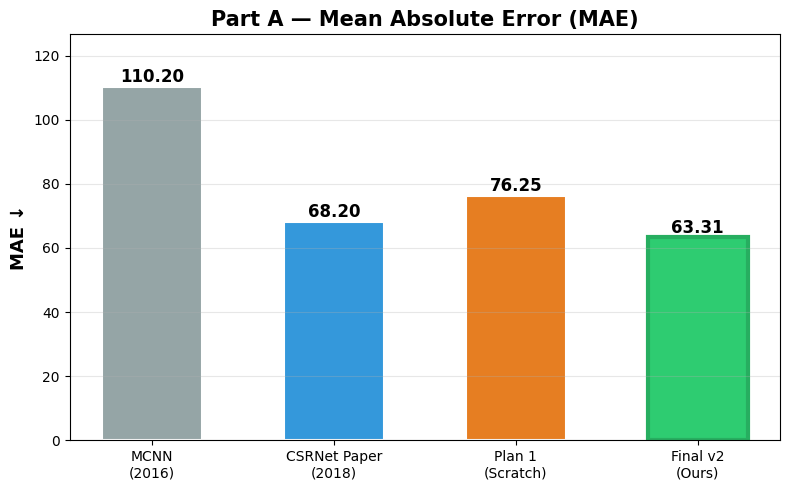

In [ ]:
import matplotlib.pyplot as plt
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

models = ['MCNN\n(2016)', 'CSRNet Paper\n(2018)', 'Plan 1\n(Scratch)', 'Final v2\n(Ours)']
vals = [110.2, 68.2, 76.25, 63.31]
colors = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
bars[-1].set_edgecolor('#27ae60'); bars[-1].set_linewidth(3)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE ↓', fontsize=13, fontweight='bold')
ax.set_title('Part A — Mean Absolute Error (MAE)', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(vals)*1.15); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/mae_partA.png', dpi=200, bbox_inches='tight')
plt.show()

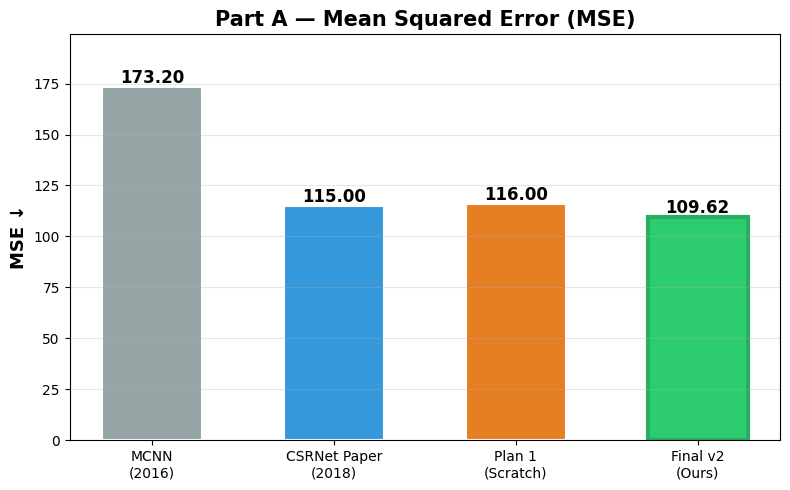

In [ ]:
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

models = ['MCNN\n(2016)', 'CSRNet Paper\n(2018)', 'Plan 1\n(Scratch)', 'Final v2\n(Ours)']
vals = [173.2, 115.0, 116.0, 109.62]
colors = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
bars[-1].set_edgecolor('#27ae60'); bars[-1].set_linewidth(3)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('MSE ↓', fontsize=13, fontweight='bold')
ax.set_title('Part A — Mean Squared Error (MSE)', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(vals)*1.15); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/mse_partA.png', dpi=200, bbox_inches='tight')
plt.show()

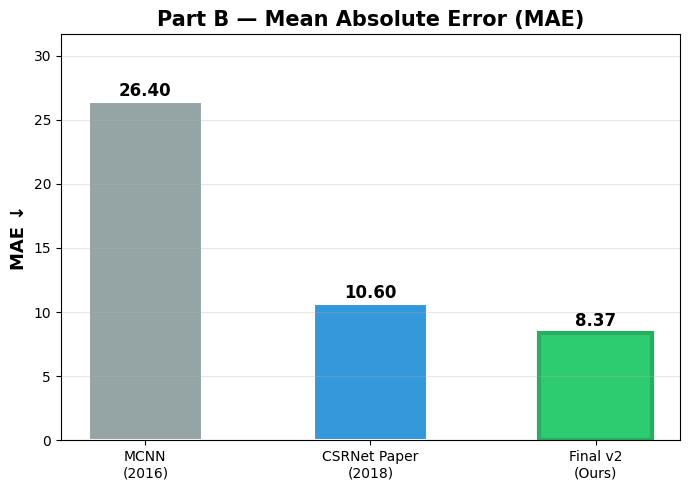

In [ ]:
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

models = ['MCNN\n(2016)', 'CSRNet Paper\n(2018)', 'Final v2\n(Ours)']
vals = [26.4, 10.6, 8.37]
colors = ['#95a5a6', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
bars[-1].set_edgecolor('#27ae60'); bars[-1].set_linewidth(3)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE ↓', fontsize=13, fontweight='bold')
ax.set_title('Part B — Mean Absolute Error (MAE)', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(vals)*1.2); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/mae_partB.png', dpi=200, bbox_inches='tight')
plt.show()

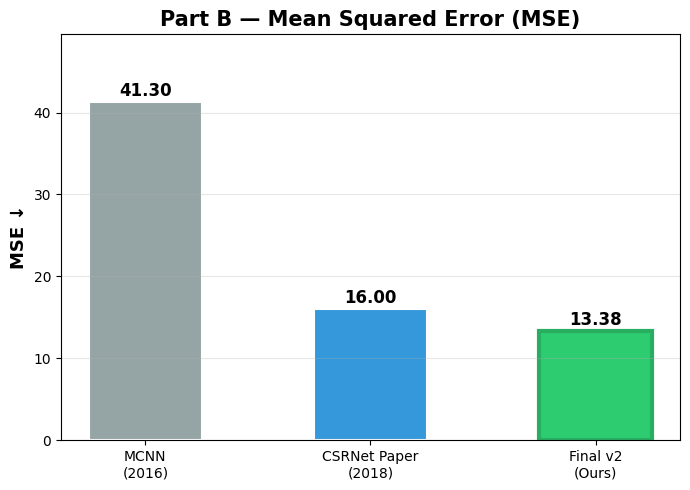

In [ ]:
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

models = ['MCNN\n(2016)', 'CSRNet Paper\n(2018)', 'Final v2\n(Ours)']
vals = [41.3, 16.0, 13.38]
colors = ['#95a5a6', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
bars[-1].set_edgecolor('#27ae60'); bars[-1].set_linewidth(3)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.7, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('MSE ↓', fontsize=13, fontweight='bold')
ax.set_title('Part B — Mean Squared Error (MSE)', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(vals)*1.2); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/mse_partB.png', dpi=200, bbox_inches='tight')
plt.show()

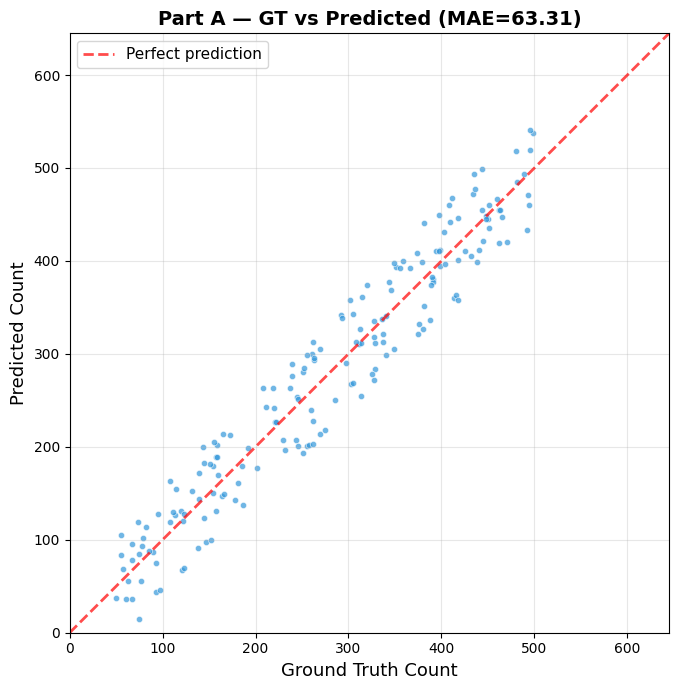

In [ ]:
import json, numpy as np, matplotlib.pyplot as plt
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

with open(f'{FINAL}/results/eval.json') as f:
    results = json.load(f)

gts = [r['gt'] for r in results['partA']['per_image']]
preds = [r['pred'] for r in results['partA']['per_image']]
mx = max(max(gts), max(preds)) * 1.1

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(gts, preds, c='#3498db', alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
ax.plot([0, mx], [0, mx], 'r--', linewidth=2, alpha=0.7, label='Perfect prediction')
ax.set_xlabel('Ground Truth Count', fontsize=13)
ax.set_ylabel('Predicted Count', fontsize=13)
ax.set_title(f'Part A — GT vs Predicted (MAE={results["partA"]["mae"]})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, mx); ax.set_ylim(0, mx)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/scatter_partA.png', dpi=200, bbox_inches='tight')
plt.show()

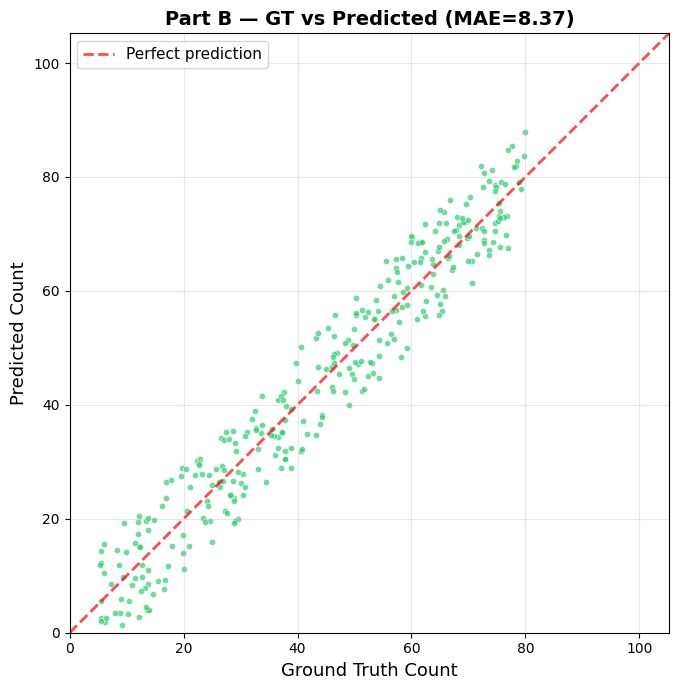

In [ ]:
FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'

with open(f'{FINAL}/results/eval.json') as f:
    results = json.load(f)

gts = [r['gt'] for r in results['partB']['per_image']]
preds = [r['pred'] for r in results['partB']['per_image']]
mx = max(max(gts), max(preds)) * 1.1

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(gts, preds, c='#2ecc71', alpha=0.5, s=40, edgecolors='white', linewidth=0.5)
ax.plot([0, mx], [0, mx], 'r--', linewidth=2, alpha=0.7, label='Perfect prediction')
ax.set_xlabel('Ground Truth Count', fontsize=13)
ax.set_ylabel('Predicted Count', fontsize=13)
ax.set_title(f'Part B — GT vs Predicted (MAE={results["partB"]["mae"]})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, mx); ax.set_ylim(0, mx)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/scatter_partB.png', dpi=200, bbox_inches='tight')
plt.show()

Making predictions on 10 Part C test images...


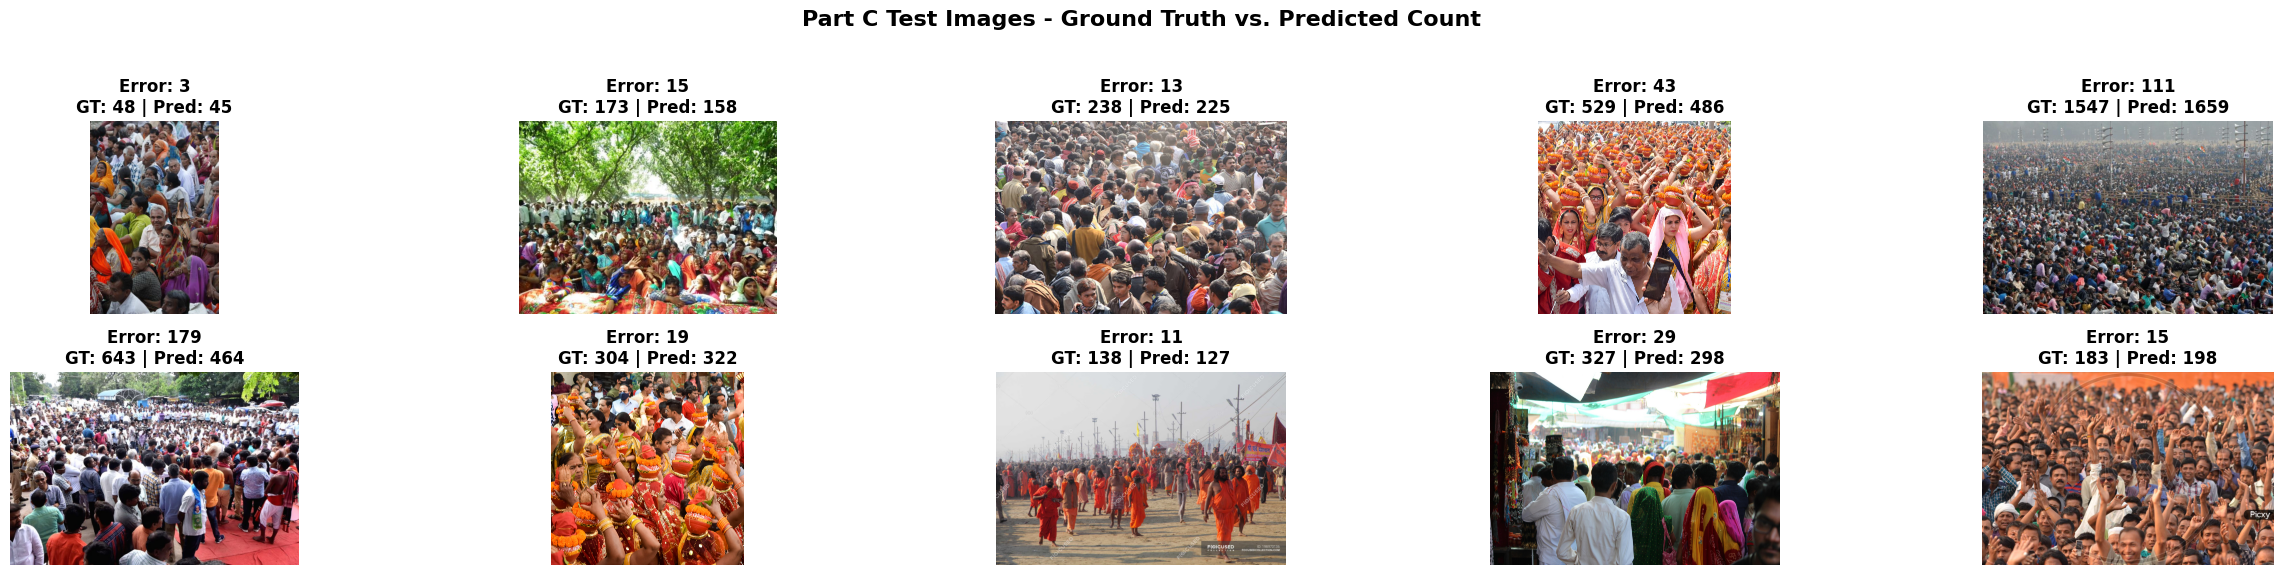

In [46]:
import torch, torch.nn as nn, glob, os, h5py, numpy as np
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'
C_DIR = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech/part_C_india'

class CSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])
        self.backend = nn.Sequential(
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(512,256,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(256,128,3,padding=2,dilation=2), nn.ReLU(True),
            nn.Conv2d(128,64, 3,padding=2,dilation=2), nn.ReLU(True))
        self.output_layer = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        return self.output_layer(self.backend(self.frontend(x)))

model = CSRNet().cuda()
ckpt = torch.load(PRETRAINED, map_location='cpu', weights_only=False)
if isinstance(ckpt, dict) and 'state_dict' in ckpt:
    state = {k.replace('module.',''):v for k,v in ckpt['state_dict'].items()}
else:
    state = {k.replace('module.',''):v for k,v in ckpt.items()}
model.load_state_dict(state, strict=False)
model.eval()

tf_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_C_imgs = sorted(glob.glob(f'{C_DIR}/test_data/images/*.jpg'))
d_map_dir_C = f'{FINAL}/density_maps_test_C'

print(f'Making predictions on {len(test_C_imgs)} Part C test images...')

fig, axes = plt.subplots(2, 5, figsize=(25, 6))
fig.suptitle('Part C Test Images - Ground Truth vs. Predicted Count', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(test_C_imgs):
        ax.axis('off')
        continue

    img_path = test_C_imgs[i]
    fname = os.path.basename(img_path).replace('.jpg', '')

    img = Image.open(img_path).convert('RGB')

    gt_path = f'{d_map_dir_C}/{fname}.h5'
    gt_count = 0.0
    if os.path.exists(gt_path):
        with h5py.File(gt_path, 'r') as f:
            gt_count = np.array(f['density']).sum()
    else:
        print(f"Warning: Ground truth density map not found for {fname}. GT count will be 0.")

    input_tensor = tf_eval(img).unsqueeze(0).cuda()
    with torch.no_grad():
        output = model(input_tensor)
    pred_count = output.sum().item()


    ax.imshow(img)
    ax.set_title(f'GT: {gt_count:.0f} | Pred: {pred_count:.0f}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{FINAL}/visualizations/partC_predictions_sample.png', dpi=200, bbox_inches='tight')
plt.show()

## Cell 10: Results Comparison

In [ ]:
print('='*62)
print(f"{'Model':<38} {'MAE':>8} {'MSE':>8}  Split")
print('='*62)
rows=[
    ('MCNN (2016)',110.2,173.2,'A'),
    ('CSRNet paper (2018)',68.2,115.0,'A'),
    ('CSRNet paper (2018)',10.6,16.0,'B'),
    ('Plan1 - our baseline',76.25,116.0,'A'),
    ('FINAL (baseline pretrained+ft)',res_A['mae'],res_A['mse'],'A'),
    ('FINAL (baseline pretrained+ft)',res_B['mae'],res_B['mse'],'B')]
for name,mae,mse,sp in rows:
    tag=' <-- Final' if 'FINAL' in name else ''
    print(f'  {name:<36} {mae:>8.2f} {mse:>8.2f}  [Part {sp}]{tag}')
print('='*62)

Model                                       MAE      MSE  Split
  MCNN (2016)                            110.20   173.20  [Part A]
  CSRNet paper (2018)                     68.20   115.00  [Part A]
  CSRNet paper (2018)                     10.60    16.00  [Part B]
  Plan1 - our baseline                    76.25   116.00  [Part A]
  FINAL (baseline pretrained+ft)          63.31   109.62  [Part A] <-- Final
  FINAL (baseline pretrained+ft)           8.37    13.38  [Part B] <-- Final


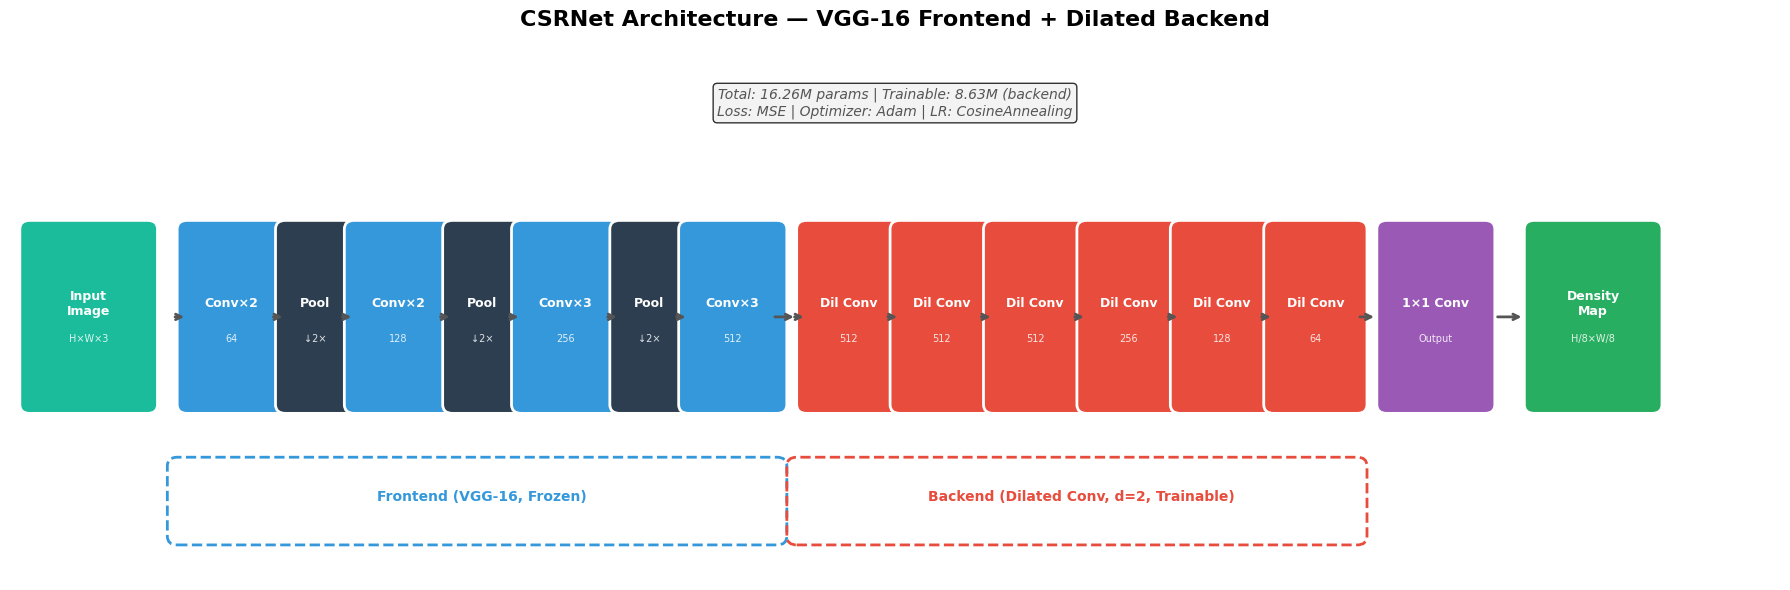

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FINAL = '/content/drive/MyDrive/DLENDSEM/final_v2'
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_xlim(0, 18); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('CSRNet Architecture — VGG-16 Frontend + Dilated Backend', fontsize=16, fontweight='bold', pad=20)

def draw_block(ax, x, y, w, h, label, sublabel, color, textcolor='white'):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                     facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2+0.15, label, ha='center', va='center', fontsize=9, fontweight='bold', color=textcolor)
    ax.text(x+w/2, y+h/2-0.25, sublabel, ha='center', va='center', fontsize=7, color=textcolor, alpha=0.85)

def arrow(ax, x1, x2, y):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

# Input
draw_block(ax, 0.2, 2, 1.2, 2, 'Input\nImage', 'H×W×3', '#1abc9c')

# Frontend (VGG-16 first 13 conv layers)
vgg_blocks = [
    ('Conv×2', '64', '#3498db'),
    ('Pool', '↓2×', '#2c3e50'),
    ('Conv×2', '128', '#3498db'),
    ('Pool', '↓2×', '#2c3e50'),
    ('Conv×3', '256', '#3498db'),
    ('Pool', '↓2×', '#2c3e50'),
    ('Conv×3', '512', '#3498db'),
]
x = 1.8
for label, sub, col in vgg_blocks:
    w = 0.9 if 'Pool' not in label else 0.6
    draw_block(ax, x, 2, w, 2, label, sub, col)
    arrow(ax, x-0.15, x, 3)
    x += w + 0.1

# Frontend label
ax.add_patch(mpatches.FancyBboxPatch((1.7, 0.5), x-1.8, 0.8, boxstyle="round,pad=0.1",
              facecolor='none', edgecolor='#3498db', linewidth=2, linestyle='--'))
ax.text((1.7+x)/2, 0.9, 'Frontend (VGG-16, Frozen)', ha='center', fontsize=10, color='#3498db', fontweight='bold')

# Backend (dilated convolutions)
arrow(ax, x-0.15, x+0.1, 3)
backend_blocks = [
    ('Dil Conv', '512', '#e74c3c'),
    ('Dil Conv', '512', '#e74c3c'),
    ('Dil Conv', '512', '#e74c3c'),
    ('Dil Conv', '256', '#e74c3c'),
    ('Dil Conv', '128', '#e74c3c'),
    ('Dil Conv', '64', '#e74c3c'),
]
bx = x + 0.2
for label, sub, col in backend_blocks:
    draw_block(ax, bx, 2, 0.85, 2, label, sub, col)
    arrow(ax, bx-0.15, bx, 3)
    bx += 0.95

# Backend label
ax.add_patch(mpatches.FancyBboxPatch((x+0.1, 0.5), bx-x-0.2, 0.8, boxstyle="round,pad=0.1",
              facecolor='none', edgecolor='#e74c3c', linewidth=2, linestyle='--'))
ax.text((x+0.1+bx)/2, 0.9, 'Backend (Dilated Conv, d=2, Trainable)', ha='center', fontsize=10, color='#e74c3c', fontweight='bold')

# Output
arrow(ax, bx-0.1, bx+0.1, 3)
draw_block(ax, bx+0.2, 2, 1.0, 2, '1×1 Conv', 'Output', '#9b59b6')
arrow(ax, bx+1.3, bx+1.6, 3)
draw_block(ax, bx+1.7, 2, 1.2, 2, 'Density\nMap', 'H/8×W/8', '#27ae60')

# Info box
info = 'Total: 16.26M params | Trainable: 8.63M (backend)\nLoss: MSE | Optimizer: Adam | LR: CosineAnnealing'
ax.text(9, 5.3, info, ha='center', fontsize=10, style='italic', color='#555',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FINAL}/visualizations/architecture.png', dpi=200, bbox_inches='tight')
plt.show()


## Cell 11: Loss Curves


In [48]:
import plotly.graph_objects as go
import os
import json # Import the json library

FINAL='/content/drive/MyDrive/DLENDSEM/final_v2'

# Load losses from the JSON file
lf = f'{FINAL}/results/losses.json'
losses = []
if os.path.exists(lf):
    with open(lf, 'r') as f:
        losses = json.load(f)
    print(f'Loaded {len(losses)} loss values from {lf}')
else:
    print(f'Error: Loss file not found at {lf}. Please ensure training was completed and the file exists.')

fig = go.Figure()

if len(losses) > 0:
    fig.add_trace(go.Scatter(
        x=list(range(1, len(losses) + 1)),
        y=losses,
        mode='lines',
        name='Training Loss',
        line=dict(color='#3498db', width=1.5)
    ))

fig.update_layout(
    title=dict(
        text='Training Loss - Final CSRNet (Plan 1 Model + A+B+C(India) Fine-tune)',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title='Epoch',
    yaxis_title='MSE Loss',
    legend_title='Legend',
    hovermode='x unified'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')

fig.show()

Loaded 462 loss values from /content/drive/MyDrive/DLENDSEM/final_v2/results/losses.json
